# Loan Approval Prediction Using Machine Learning

## Objective

Build a machine learning model to predict whether a loan application
will be Approved or Rejected based on applicant information.

## Goals

- Perform data cleaning and preprocessing
- Explore important features affecting loan approval
- Handle missing values
- Encode categorical variables
- Handle class imbalance
- Train classification models
- Evaluate model performance
- Provide business insights for loan approval decisions


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from google.colab import files

uploaded = files.upload()


Saving archive (1).zip to archive (1).zip


In [6]:
import zipfile
import os

zip_file = 'archive (1).zip'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/loan_data')

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [7]:
os.listdir('/content/loan_data')

['loan_prediction.csv']

In [11]:
import os

print("Files and folders inside loan_data:")
print(os.listdir('/content/loan_data'))

Files and folders inside loan_data:
['loan_prediction.csv']


In [12]:
import os

for root, dirs, files in os.walk('/content/loan_data'):
    for file in files:
        print(os.path.join(root, file))

/content/loan_data/loan_prediction.csv


In [13]:
import os

for root, dirs, files in os.walk('/content/loan_data'):
    for file in files:
        print(os.path.join(root, file))

/content/loan_data/loan_prediction.csv


In [14]:
import os
import pandas as pd

csv_files = []

for root, dirs, files in os.walk('/content/loan_data'):
    for file in files:
        if file.lower().endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
/content/loan_data/loan_prediction.csv


In [15]:
df = pd.read_csv(csv_files[0])

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [16]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [17]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 614
Columns: 13


In [18]:
print(df.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [20]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [21]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
for column in df.columns:
    print("\nColumn:", column)
    print(df[column].value_counts().head(10))


Column: Loan_ID
Loan_ID
LP002990    1
LP001002    1
LP001003    1
LP001005    1
LP001006    1
LP001008    1
LP002943    1
LP002941    1
LP002940    1
LP002938    1
Name: count, dtype: int64

Column: Gender
Gender
Male      489
Female    112
Name: count, dtype: int64

Column: Married
Married
Yes    398
No     213
Name: count, dtype: int64

Column: Dependents
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

Column: Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Column: Self_Employed
Self_Employed
No     500
Yes     82
Name: count, dtype: int64

Column: ApplicantIncome
ApplicantIncome
2500    9
4583    6
6000    6
2600    6
5000    5
3750    5
4166    5
3333    5
2400    4
8333    4
Name: count, dtype: int64

Column: CoapplicantIncome
CoapplicantIncome
0.0       273
1666.0      5
2083.0      5
2500.0      5
1625.0      3
1459.0      3
1800.0      3
1750.0      3
2333.0      3
2250.0      3
Name: count, dtype: int64

Col

In [24]:
print(df.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [26]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [27]:
print(df['Loan_Status'].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [28]:
print(df['Loan_Status'].value_counts(normalize=True) * 100)

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


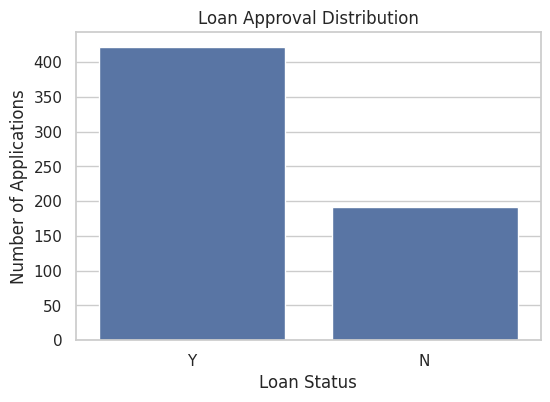

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Loan_Status')

plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applications')

plt.show()

In [30]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [31]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (614, 13)


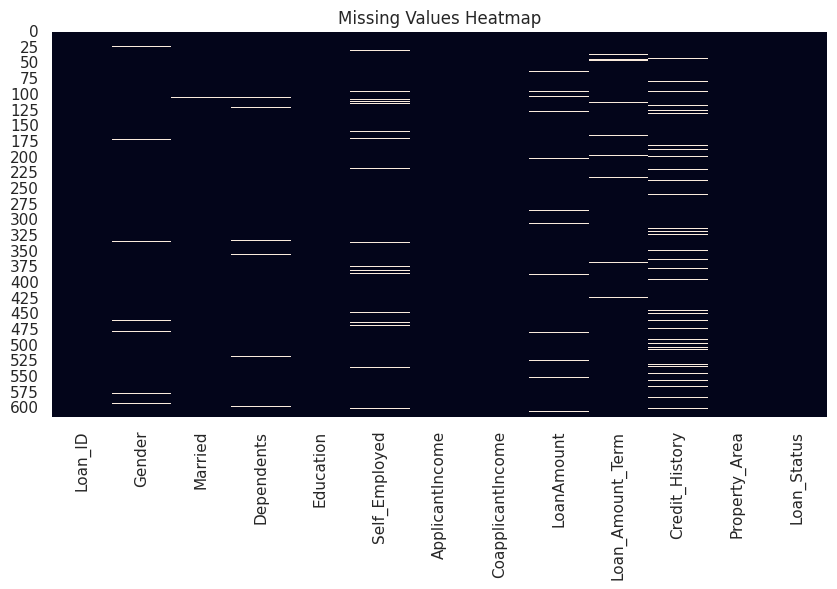

In [32]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title('Missing Values Heatmap')
plt.show()

In [33]:
categorical_columns = df.select_dtypes(include='object').columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [34]:
for column in categorical_columns:
    print("\n" + "="*40)
    print(column)
    print(df[column].value_counts(dropna=False))


Loan_ID
Loan_ID
LP002990    1
LP001002    1
LP001003    1
LP001005    1
LP001006    1
           ..
LP001024    1
LP001020    1
LP001018    1
LP001014    1
LP001013    1
Name: count, Length: 614, dtype: int64

Gender
Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

Married
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

Dependents
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Self_Employed
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64

Property_Area
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Loan_Status
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [38]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [39]:
df['Loan_ID'].head()

,Loan_ID
0,LP001002
1,LP001003
2,LP001005
3,LP001006
4,LP001008


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [41]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [42]:
df = df.drop('Loan_ID', axis=1)

print("Loan_ID removed successfully!")
print(df.shape)

Loan_ID removed successfully!
(614, 12)


In [43]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 11)
Target shape: (614,)


In [44]:
print(y.value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [45]:
y = y.map({'Y': 1, 'N': 0})

print(y.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [46]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numerical columns:")
print(list(numeric_features))

print("\nCategorical columns:")
print(list(categorical_features))

Numerical columns:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical columns:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 11)
Testing data: (123, 11)


In [48]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [54]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [55]:
!pip install imbalanced-learn -q

In [56]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("SMOTE ready!")

SMOTE ready!


In [57]:
from sklearn.linear_model import LogisticRegression

logistic_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression pipeline created!")

Logistic Regression pipeline created!


In [58]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [59]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions completed successfully!")

Predictions completed successfully!


In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Logistic Regression Results")
print("-" * 40)

print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall   :", round(recall_score(y_test, y_pred_lr), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_lr), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lr), 4))

Logistic Regression Results
----------------------------------------
Accuracy : 0.8211
Precision: 0.8621
Recall   : 0.8824
F1 Score : 0.8721
ROC-AUC  : 0.8759


In [61]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Rejected', 'Approved']
))

              precision    recall  f1-score   support

    Rejected       0.72      0.68      0.70        38
    Approved       0.86      0.88      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.79       123
weighted avg       0.82      0.82      0.82       123



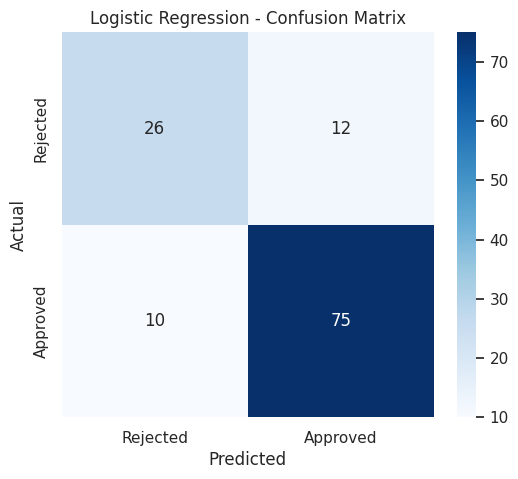

In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [63]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

print("Decision Tree pipeline created!")

Decision Tree pipeline created!


In [64]:
decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [65]:
y_pred_dt = decision_tree_model.predict(X_test)

y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions completed!")

Decision Tree predictions completed!


In [66]:
print("Decision Tree Results")
print("-" * 40)

print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dt), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_dt), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_dt), 4))

Decision Tree Results
----------------------------------------
Accuracy : 0.7561
Precision: 0.8022
Recall   : 0.8588
F1 Score : 0.8295
ROC-AUC  : 0.7005


In [67]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ))
])

print("Random Forest pipeline created!")

Random Forest pipeline created!


In [68]:
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [69]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [70]:
print("Random Forest Results")
print("-" * 40)

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

Random Forest Results
----------------------------------------
Accuracy : 0.7805
Precision: 0.8222
Recall   : 0.8706
F1 Score : 0.8457
ROC-AUC  : 0.8152


In [71]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8211,0.8621,0.8824,0.8721,0.8759
1,Decision Tree,0.7561,0.8022,0.8588,0.8295,0.7005
2,Random Forest,0.7805,0.8222,0.8706,0.8457,0.8152


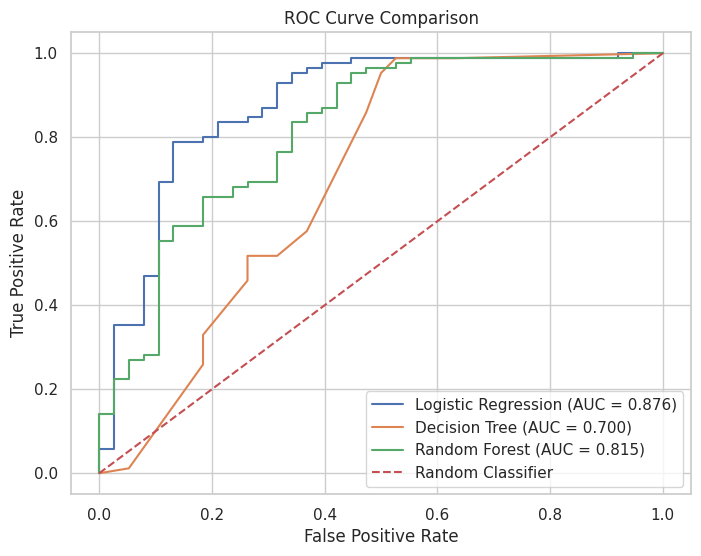

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})'
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})'
)

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)

plt.show()

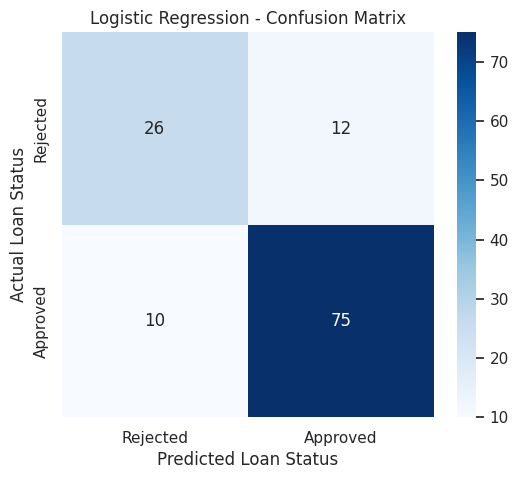

In [73]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Loan Status')
plt.ylabel('Actual Loan Status')

plt.show()

In [74]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    predictions = (y_prob_lr >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_test, predictions, zero_division=0
        ),
        'Recall': recall_score(
            y_test, predictions, zero_division=0
        ),
        'F1 Score': f1_score(
            y_test, predictions, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df = threshold_df.round(4)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.3,0.8317,0.9882,0.9032
1,0.4,0.8300,0.9765,0.8973
2,0.5,0.8621,0.8824,0.8721
3,0.6,0.9333,0.6588,0.7724
4,0.7,0.9143,0.3765,0.5333


In [75]:
y_prob_lr

array([0.02557314, 0.75095942, 0.5565535 , 0.53468416, 0.77065217,
       0.71402513, 0.77121437, 0.70935144, 0.53106503, 0.5976193 ,
       0.74114833, 0.75955153, 0.73226813, 0.60349264, 0.03948078,
       0.04880703, 0.49993868, 0.06021449, 0.04826573, 0.55763499,
       0.03488965, 0.43647687, 0.44670892, 0.72394502, 0.74341373,
       0.67858781, 0.60176731, 0.8570957 , 0.05701436, 0.59773544,
       0.65230986, 0.80349738, 0.64611296, 0.62290711, 0.50267145,
       0.79154554, 0.02419994, 0.76786393, 0.52272495, 0.74850224,
       0.711092  , 0.47434408, 0.53290348, 0.59658054, 0.57009329,
       0.57921998, 0.7595943 , 0.48841428, 0.78993099, 0.39202205,
       0.04820622, 0.82672376, 0.02013745, 0.77364474, 0.41449001,
       0.58870105, 0.06292341, 0.64162513, 0.73670295, 0.61447367,
       0.03165547, 0.45357102, 0.50477649, 0.78757914, 0.53269836,
       0.49374909, 0.69972766, 0.69719086, 0.67583667, 0.64149939,
       0.70946922, 0.10374421, 0.81637316, 0.55447738, 0.69849

In [76]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    predictions = (y_prob_lr >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_test, predictions, zero_division=0
        ),
        'Recall': recall_score(
            y_test, predictions, zero_division=0
        ),
        'F1 Score': f1_score(
            y_test, predictions, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results).round(4)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.3,0.8317,0.9882,0.9032
1,0.4,0.8300,0.9765,0.8973
2,0.5,0.8621,0.8824,0.8721
3,0.6,0.9333,0.6588,0.7724
4,0.7,0.9143,0.3765,0.5333


In [77]:
best_threshold_row = threshold_df.loc[
    threshold_df['F1 Score'].idxmax()
]

print("Best threshold based on F1-score:")
print(best_threshold_row)

Best threshold based on F1-score:
Threshold    0.3000
Precision    0.8317
Recall       0.9882
F1 Score     0.9032
Name: 0, dtype: float64


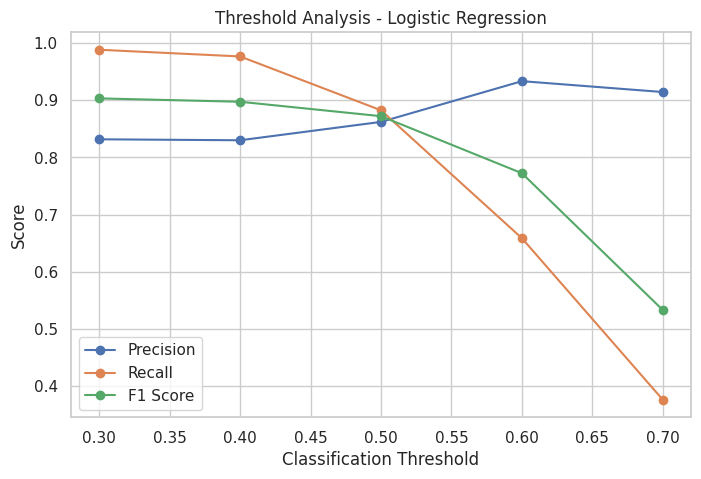

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1 Score'],
    marker='o',
    label='F1 Score'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Threshold Analysis - Logistic Regression')
plt.legend()
plt.grid(True)

plt.show()

In [80]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    predictions = (y_prob_lr >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1 Score': f1_score(y_test, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results).round(4)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.3,0.8317,0.9882,0.9032
1,0.4,0.8300,0.9765,0.8973
2,0.5,0.8621,0.8824,0.8721
3,0.6,0.9333,0.6588,0.7724
4,0.7,0.9143,0.3765,0.5333


In [81]:
best_threshold_row = threshold_df.loc[
    threshold_df['F1 Score'].idxmax()
]

print("Best threshold based on F1-score:")
print(best_threshold_row)

Best threshold based on F1-score:
Threshold    0.3000
Precision    0.8317
Recall       0.9882
F1 Score     0.9032
Name: 0, dtype: float64


In [82]:
recommended_threshold = best_threshold_row['Threshold']

print("Recommended deployment threshold:",
      recommended_threshold)

Recommended deployment threshold: 0.3


In [83]:
final_predictions = (
    y_prob_lr >= recommended_threshold
).astype(int)

print("Final predictions created successfully!")

Final predictions created successfully!


In [84]:
print("Final Model Performance")
print("-" * 40)

print("Precision:",
      round(precision_score(y_test, final_predictions), 4))

print("Recall:",
      round(recall_score(y_test, final_predictions), 4))

print("F1 Score:",
      round(f1_score(y_test, final_predictions), 4))

Final Model Performance
----------------------------------------
Precision: 0.8317
Recall: 0.9882
F1 Score: 0.9032


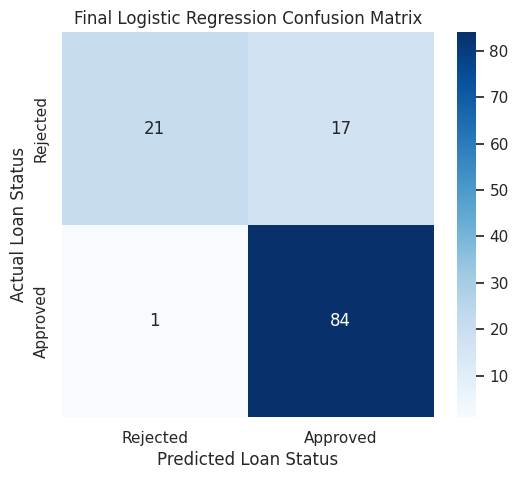

In [86]:
from sklearn.metrics import confusion_matrix

final_cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.title('Final Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Loan Status')
plt.ylabel('Actual Loan Status')

plt.show()

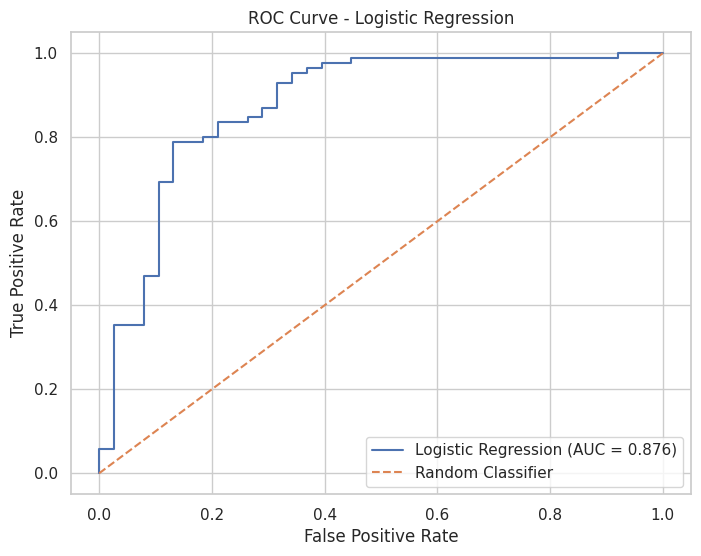

In [87]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)

plt.show()

In [88]:
feature_names = (
    logistic_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps['classifier']
    .coef_[0]
)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance['Absolute_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
4,num__Credit_History,1.264772,1.264772
18,cat__Property_Area_Semiurban,0.485655,0.485655
17,cat__Property_Area_Rural,-0.357239,0.357239
11,cat__Dependents_2,0.276412,0.276412
10,cat__Dependents_1,-0.226144,0.226144
2,num__LoanAmount,-0.185815,0.185815
9,cat__Dependents_0,-0.182553,0.182553
13,cat__Education_Graduate,0.176153,0.176153
14,cat__Education_Not Graduate,-0.175560,0.175560
0,num__ApplicantIncome,0.144487,0.144487


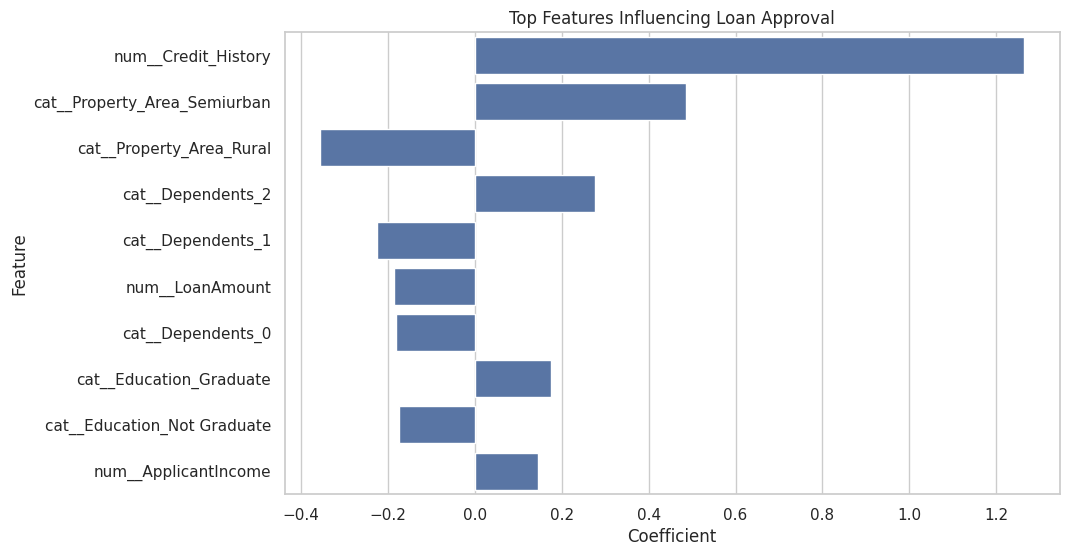

In [89]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title('Top Features Influencing Loan Approval')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

In [90]:
final_results = results.copy()

final_results = final_results.round(4)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8211,0.8621,0.8824,0.8721,0.8759
1,Decision Tree,0.7561,0.8022,0.8588,0.8295,0.7005
2,Random Forest,0.7805,0.8222,0.8706,0.8457,0.8152


In [91]:
final_results.to_csv(
    'loan_model_comparison.csv',
    index=False
)

threshold_df.to_csv(
    'loan_threshold_analysis.csv',
    index=False
)

print("Result files created successfully!")

Result files created successfully!


## Business Interpretation

The Logistic Regression model achieved the best overall performance among
the three tested classification models. It achieved an accuracy of 82.11%,
precision of 86.21%, recall of 88.24%, F1-score of 87.21%, and ROC-AUC of
87.59%.

The model can help financial institutions assess loan applications by
estimating the probability of loan approval from applicant information.

A probability threshold can be adjusted according to business requirements.
A lower threshold may approve more applicants but can increase the risk of
incorrect approvals. A higher threshold provides a more conservative
decision strategy but may reject some potentially eligible applicants.

Therefore, threshold selection should consider the relative business cost
of false approvals and false rejections.

The model should be used as a decision-support tool rather than as the sole
basis for loan decisions. Human review, lending policies, regulatory
requirements, and other financial information should also be considered.

## Model Comparison

Three classification algorithms were evaluated: Logistic Regression,
Decision Tree, and Random Forest.

Logistic Regression performed best across all major evaluation metrics. It
achieved the highest accuracy, precision, recall, F1-score, and ROC-AUC.

Decision Tree produced the lowest overall performance, particularly in terms
of ROC-AUC, which was 0.7005.

Random Forest performed better than the Decision Tree but did not outperform
Logistic Regression on the evaluation metrics.

Based on the results, Logistic Regression was selected as the final model for
this loan approval prediction task.

## Conclusion

This project developed a supervised machine learning system for predicting
loan approval using applicant information.

The data preprocessing stage included missing-value handling, categorical
encoding, numerical feature scaling, and removal of the Loan_ID identifier.
SMOTE was applied to the training data to address class imbalance.

Three classification models were trained and compared: Logistic Regression,
Decision Tree, and Random Forest.

Logistic Regression was selected as the final model because it achieved the
best overall performance, with an accuracy of 82.11%, precision of 86.21%,
recall of 88.24%, F1-score of 87.21%, and ROC-AUC of 87.59%.

Threshold analysis was also performed to understand the trade-off between
precision and recall. The selected threshold can be adjusted according to
the financial institution's risk tolerance and business objectives.

Overall, the developed model can support loan officers in making more
consistent and data-driven decisions while retaining human oversight for
final lending decisions.